<a href="https://colab.research.google.com/github/Maayureshh/Phishing-URL-detector/blob/main/Phishing_URL_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()
fname = list(uploaded.keys())[0]
print("Loaded:", fname)

Saving phishing_site_urls.csv to phishing_site_urls.csv
Loaded: phishing_site_urls.csv


In [2]:
import re, math
import numpy as np
import pandas as pd

raw = pd.read_csv(fname)
print("Shape:", raw.shape)
print("Columns:", raw.columns.tolist())

URL_COL = "URL"
LABEL_COL = "Label"
PHISHING_VALUES = ["bad"]     # label values that mean PHISHING
KEEP_VALUES = None            # None = keep all labels. Only for the Malicious URLs file: ["benign", "phishing"]


def find_col(name):
    for c in raw.columns:
        if c.lower() == name.lower():
            return c
    raise ValueError(f"Column '{name}' not found. Columns in your file: {raw.columns.tolist()}")

url_c, label_c = find_col(URL_COL), find_col(LABEL_COL)
print("\nRaw label values:")
print(raw[label_c].value_counts().head(10))

df = raw[[url_c, label_c]].dropna()
df.columns = ["url", "label"]
df["label"] = df["label"].astype(str).str.lower()

if KEEP_VALUES:
    df = df[df["label"].isin([v.lower() for v in KEEP_VALUES])]

df["label"] = df["label"].isin([str(v).lower() for v in PHISHING_VALUES]).astype(int)   # 1 = phishing, 0 = legitimate

counts = df["label"].value_counts()
print("\nClass counts (1 = phishing):")
print(counts)
assert df["label"].nunique() == 2, "Only one class found. Check PHISHING_VALUES against the raw label values printed above."
assert counts.min() / len(df) > 0.05, "Extremely imbalanced file (a class is under 5%). Wrong dataset? Do not use it for results."

print("\nSample PHISHING:")
for u in df[df.label == 1]["url"].sample(5, random_state=1): print("  ", u[:90])
print("\nSample LEGITIMATE:")
for u in df[df.label == 0]["url"].sample(5, random_state=1): print("  ", u[:90])

def strip_scheme(u):
    u = u.strip()
    u = re.sub(r"^[a-zA-Z][a-zA-Z0-9+.-]*://", "", u)
    return re.sub(r"^www\.", "", u)

df["url"] = df["url"].map(strip_scheme)
df = df[df["url"].str.len() > 3]

conflict = df.groupby("url")["label"].nunique()
conflict = conflict[conflict > 1].index
df = df[~df["url"].isin(conflict)].drop_duplicates("url")
print("\nAfter cleaning:", len(df))
print(df["label"].value_counts())

SAMPLE_N = 100_000   # set to None to use everything (slower)
if SAMPLE_N and len(df) > SAMPLE_N:
    df = df.groupby("label").sample(frac=SAMPLE_N / len(df), random_state=42)   # keeps the class ratio
df = df.reset_index(drop=True)
print("Rows used:", len(df))
df.head()


Shape: (549346, 2)
Columns: ['URL', 'Label']

Raw label values:
Label
good    392924
bad     156422
Name: count, dtype: int64

Class counts (1 = phishing):
label
0    392924
1    156422
Name: count, dtype: int64

Sample PHISHING:
   www.hongfazhileng.com/css/?secure.runescape.com/m=weblogin/loginform.ws?mod=www&amp;comodm
   annakraktour.pl/World/gucci2014/gdocs/pvalidate.html?ip=149.20.54.229
   deltaaviation-sd.com/newpdfadobe/PDF/PDF%20MINE/index.html
   mujtabatrading.com/ujfcw6aq
   www.tassnews.net/

Sample LEGITIMATE:
   rootsweb.ancestry.com/~abwcobit/Data/SD/1996/1996EdmontonPage2.html
   inquisitr.com/98639/2010-new-york-jets-season-in-review/
   www.adastra.de/en/mission_e.php
   en.wikipedia.org/wiki/Paul_V._Lacoste
   moray.anglican.org/index.php/news/entry/new_bishop_for_argyle_the_isles/

After cleaning: 506416
label
0    392869
1    113547
Name: count, dtype: int64
Rows used: 100000


,url,label
0,symmetryperfect.com/shots,0
1,conneroutdoors.com/hunting/quebec.html,0
2,chiark.greenend.org.uk/~pmaydell/PERQ/,0
3,wkyc.com/,0
4,en.wikipedia.org/wiki/2009_Oakland_Raiders_season,0


In [3]:
KEYWORDS = ["login", "verify", "update", "secure", "account", "bank", "confirm", "signin",
            "password", "paypal", "webscr", "ebay", "free", "bonus", "wallet"]
SUSPICIOUS_TLDS = {"xyz", "top", "tk", "ml", "ga", "cf", "gq", "click", "work", "loan", "zip", "country"}
SHORTENERS = {"bit.ly", "tinyurl.com", "goo.gl", "t.co", "ow.ly", "is.gd", "buff.ly", "rebrand.ly"}
IP_RE = re.compile(r"^\d{1,3}(\.\d{1,3}){3}$")

def entropy(s):
    if not s:
        return 0.0
    p = [s.count(c) / len(s) for c in set(s)]
    return -sum(x * math.log2(x) for x in p)

def extract_features(u):
    host_port, _, rest = u.partition("/")
    host_port = host_port.split("@")[-1]
    host = host_port.split(":")[0].lower()
    path, _, query = ("/" + rest).partition("?")
    labels = host.split(".")
    tld = labels[-1] if len(labels) > 1 else ""
    low = u.lower()
    n = len(u)
    digits = sum(c.isdigit() for c in u)
    return {
        "url_length": n,
        "host_length": len(host),
        "path_length": len(path),
        "query_length": len(query),
        "num_dots": u.count("."),
        "num_hyphens": u.count("-"),
        "num_underscores": u.count("_"),
        "num_digits": digits,
        "digit_ratio": digits / n,
        "num_special": sum(not c.isalnum() for c in u),
        "num_percent": u.count("%"),
        "has_at": int("@" in u),
        "double_slash_in_path": int("//" in rest),
        "is_ip_host": int(bool(IP_RE.match(host))),
        "has_port": int(":" in host_port),
        "num_subdomains": max(len(labels) - 2, 0),
        "host_hyphens": host.count("-"),
        "host_digits": sum(c.isdigit() for c in host),
        "host_entropy": entropy(host),
        "suspicious_tld": int(tld in SUSPICIOUS_TLDS),
        "is_shortener": int(host in SHORTENERS),
        "num_keywords": sum(k in low for k in KEYWORDS),
        "path_depth": len([p for p in path.split("/") if p]),
        "num_params": (query.count("&") + 1) if query else 0,
        "longest_token": max((len(t) for t in re.split(r"[^A-Za-z0-9]+", u)), default=0),
    }

def reg_domain(u):
    host = u.partition("/")[0].split("@")[-1].split(":")[0].lower()
    return ".".join(host.split(".")[-2:])

X = pd.DataFrame([extract_features(u) for u in df["url"]])
y = df["label"].values
groups = df["url"].map(reg_domain).values
print("Feature matrix:", X.shape)
X.head()

Feature matrix: (100000, 25)


,url_length,host_length,path_length,query_length,num_dots,num_hyphens,num_underscores,num_digits,digit_ratio,num_special,...,num_subdomains,host_hyphens,host_digits,host_entropy,suspicious_tld,is_shortener,num_keywords,path_depth,num_params,longest_token
0,25,19,6,0,1,0,0,0,0.000000,2,...,0,0,0,3.326360,0,0,0,1,0,15
1,38,18,20,0,2,0,0,0,0.000000,4,...,0,0,0,3.191612,0,0,0,2,0,14
2,38,22,16,0,3,0,0,0,0.000000,7,...,2,0,0,3.538311,0,0,0,2,0,8
3,9,8,1,0,1,0,0,0,0.000000,2,...,0,0,0,2.750000,0,0,0,0,0,4
4,49,16,33,0,2,0,3,4,0.081633,7,...,1,0,0,3.452820,0,0,0,2,0,9


In [4]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
print("Train:", len(X_train), "| Test:", len(X_test))
print("Phishing share  train: %.2f  test: %.2f" % (y_train.mean(), y_test.mean()))

Train: 82185 | Test: 17815
Phishing share  train: 0.22  test: 0.24


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced")),
    "Random Forest": RandomForestClassifier(n_estimators=200, n_jobs=-1, class_weight="balanced", random_state=42),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=42),
}

rows, fitted = [], {}
for name, m in models.items():
    m.fit(X_train, y_train)
    fitted[name] = m
    pred = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })

results = pd.DataFrame(rows).set_index("Model").round(4)
results

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.8033,0.5782,0.6324,0.6041,0.8325
Random Forest,0.8846,0.8096,0.6719,0.7343,0.9112
Gradient Boosting,0.8816,0.8387,0.6201,0.7130,0.9181


In [7]:
from sklearn.model_selection import GroupKFold, cross_val_score

best_name = results["F1"].idxmax()
print("Best model by F1:", best_name)
cv_scores = cross_val_score(models[best_name], X, y, groups=groups, cv=GroupKFold(n_splits=5), scoring="f1", n_jobs=1)
print("5-fold grouped CV F1:", cv_scores.round(4))
print("Mean: %.4f  Std: %.4f" % (cv_scores.mean(), cv_scores.std()))

Best model by F1: Random Forest
5-fold grouped CV F1: [0.7199 0.7815 0.7282 0.7016 0.7313]
Mean: 0.7325  Std: 0.0266


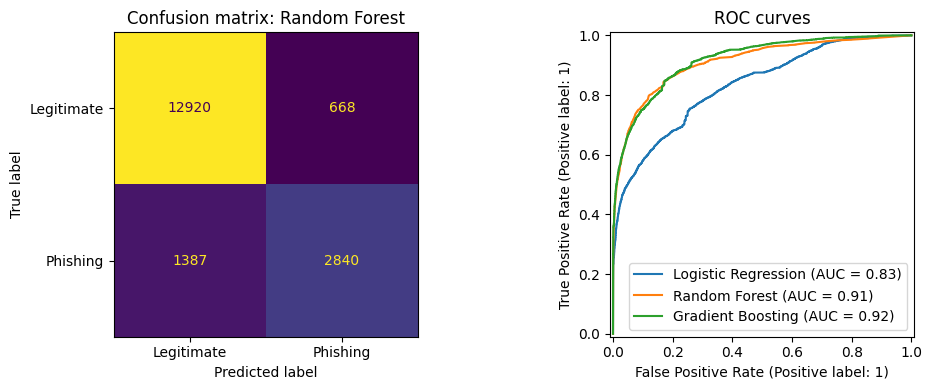

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

best = fitted[best_name]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_estimator(best, X_test, y_test, display_labels=["Legitimate", "Phishing"], ax=ax[0], colorbar=False)
ax[0].set_title(f"Confusion matrix: {best_name}")
for name, m in fitted.items():
    RocCurveDisplay.from_estimator(m, X_test, y_test, ax=ax[1], name=name)
ax[1].set_title("ROC curves")
plt.tight_layout()
plt.show()

longest_token    0.1097
host_entropy     0.1018
path_length      0.0815
num_keywords     0.0808
url_length       0.0748
num_dots         0.0710
num_digits       0.0637
host_length      0.0627
digit_ratio      0.0569
path_depth       0.0557
dtype: float64


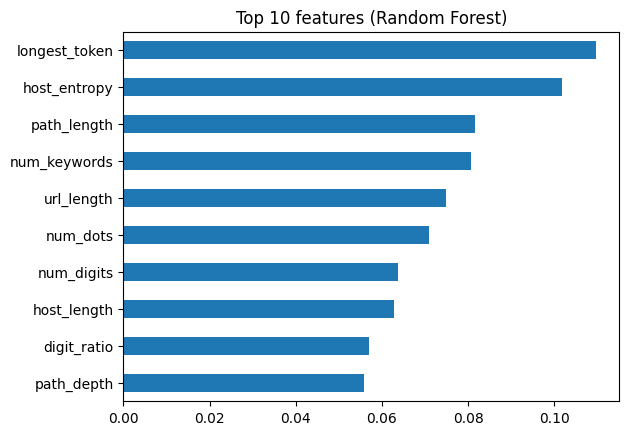

In [9]:
rf = fitted["Random Forest"]
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(imp.head(10).round(4))
imp.head(10).plot(kind="barh", title="Top 10 features (Random Forest)").invert_yaxis()
plt.show()

In [10]:
test_df = df.iloc[test_idx].copy()
test_df["pred"] = best.predict(X_test)

fp = test_df[(test_df.label == 0) & (test_df.pred == 1)]   # legit flagged as phishing
fn = test_df[(test_df.label == 1) & (test_df.pred == 0)]   # phishing missed
print(f"False positives: {len(fp)} | False negatives: {len(fn)}\n")
print("--- Legitimate URLs flagged as phishing ---")
for u in fp["url"].head(10): print(" ", u[:100])
print("\n--- Phishing URLs missed ---")
for u in fn["url"].head(10): print(" ", u[:100])

False positives: 668 | False negatives: 1387

--- Legitimate URLs flagged as phishing ---
  bessel.org/cwgfunio.htm
  darkshire.net/~jhkim/rpg/theory/
  cafepress.com/as18
  ftp.inf.tu-dresden.de/pub/os/linux/documentation/howto/Secure-Programs-HOWTO
  flowershopnetwork.com/florists/CA/AB/Leduc
  viadeo.com/en/profile/yann.aubry1
  freerepublic.com/focus/f-news/2769343/posts
  kadmy.com/another.html
  homefinder.com/TN/Selmer/
  commercialtrucktrader.com/research/

--- Phishing URLs missed ---
  pathba.com/wp-includes/P3GvS4YXVCh
  pastehtml.com/view/bebowvqx1.html
  moviedownloader.net/d/GraboidMovieDownloader-3.54.exe
  wh.ilvyou.cc/domestic/list/20-0-350000-0-0-1-0-0-0-2-0-0-0-0-0-0-1.html
  misalange.com/ebay-item-277263929383/
  dedivan.ru/printable.php?productID=143
  latesttalent.com/datepicker/javascript/m4gzkzvh.php?id=1697136
  waaynet.com/confidential/file/yinput
  textidea.com/rss/feed/stream/
  directxex.com/uploads/1738599339.ms1.exe?dl=11738599339.ms1.exe


In [11]:
import joblib

def check_url(url):
    feats = pd.DataFrame([extract_features(strip_scheme(url))])
    p = best.predict_proba(feats)[0][1]
    verdict = "PHISHING" if p >= 0.5 else "LEGITIMATE"
    print(f"{url}\n  -> {verdict} (phishing probability {p*100:.1f}%)\n")
    return p

for u in ["https://www.github.com/about",
          "http://secure-paypal-update44.xyz/login.php?id=8841",
          "http://192.168.4.20/verify/account.html"]:
    check_url(u)

joblib.dump(best, "phishing_model.pkl")
files.download("phishing_model.pkl")

https://www.github.com/about
  -> LEGITIMATE (phishing probability 22.1%)

http://secure-paypal-update44.xyz/login.php?id=8841
  -> PHISHING (phishing probability 70.0%)

http://192.168.4.20/verify/account.html
  -> PHISHING (phishing probability 99.0%)



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
!pip install -q gradio
import gradio as gr

def predict(url):
    feats = pd.DataFrame([extract_features(strip_scheme(url))])
    p = float(best.predict_proba(feats)[0][1])
    return {"Phishing": p, "Legitimate": 1 - p}

demo = gr.Interface(fn=predict,
                    inputs=gr.Textbox(label="Paste a URL"),
                    outputs=gr.Label(num_top_classes=2),
                    title="Phishing URL Detector")
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4d61ec50c122188fc4.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
